In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('diabetes.csv')

In [3]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
data.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [5]:
data.rename(columns={'DiabetesPedigreeFunction' : 'DBF'},inplace=True)
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DBF,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Pregnancies    768 non-null    int64  
 1   Glucose        768 non-null    int64  
 2   BloodPressure  768 non-null    int64  
 3   SkinThickness  768 non-null    int64  
 4   Insulin        768 non-null    int64  
 5   BMI            768 non-null    float64
 6   DBF            768 non-null    float64
 7   Age            768 non-null    int64  
 8   Outcome        768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
data.isnull().sum()

Pregnancies      0
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
DBF              0
Age              0
Outcome          0
dtype: int64

In [8]:
data.shape

(768, 9)

#### there is no null value but some columns contains 0 which is not valide so we need to replace that zeros with median

In [9]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

for col in cols:
    data[col] = data[col].replace(0, data[col].median())

In [10]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DBF,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,27.334635,94.652344,32.450911,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,9.229014,105.547598,6.875366,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,23.000000,30.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,31.250000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


#### All columns are numeric soo no need of encoding.. Also not found any null values

### Visulization:

#### 1. Histogram

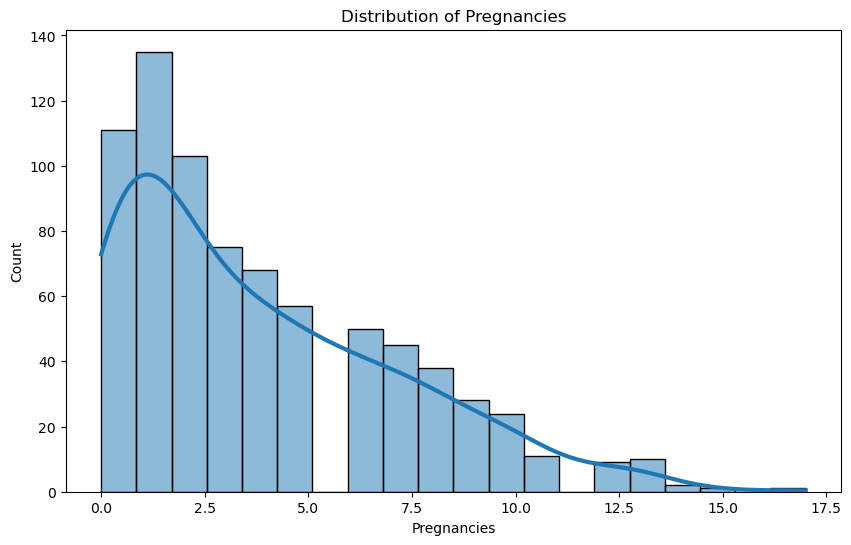

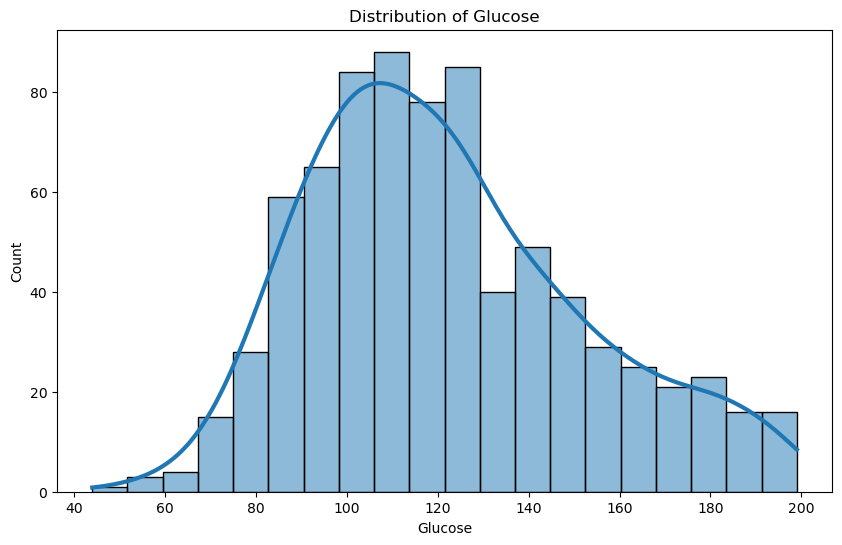

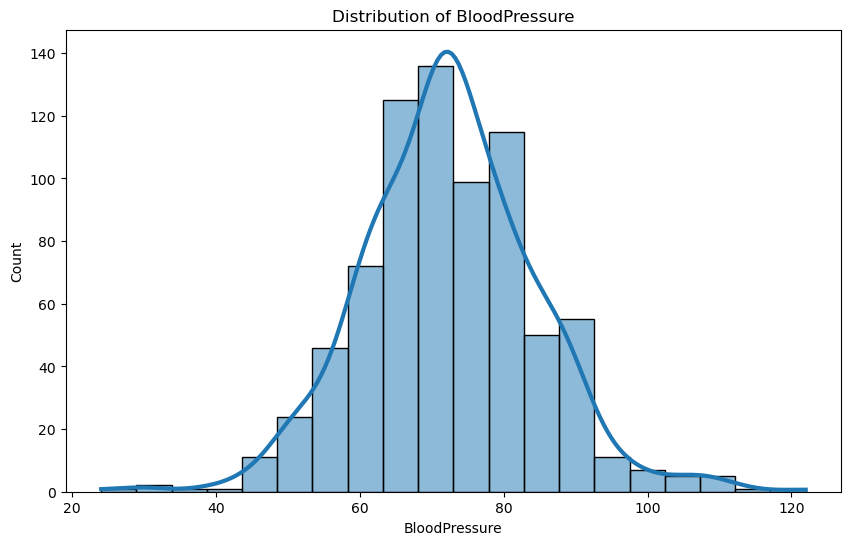

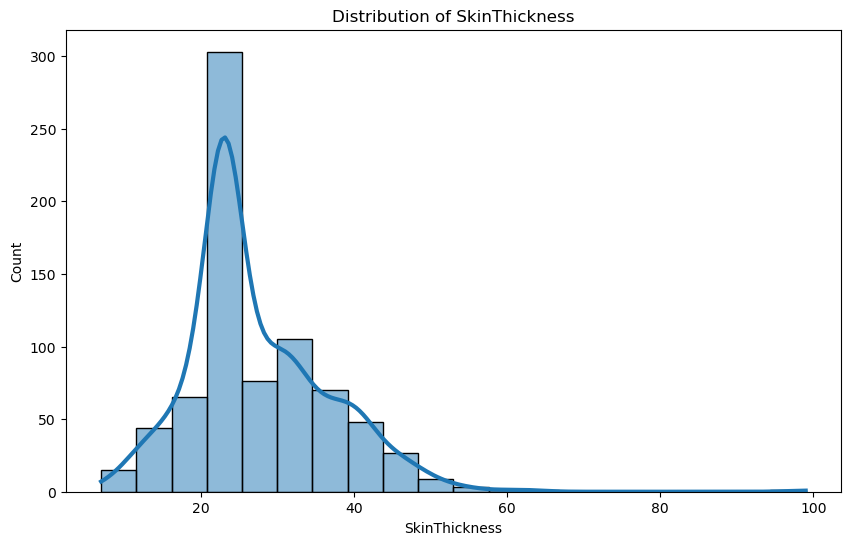

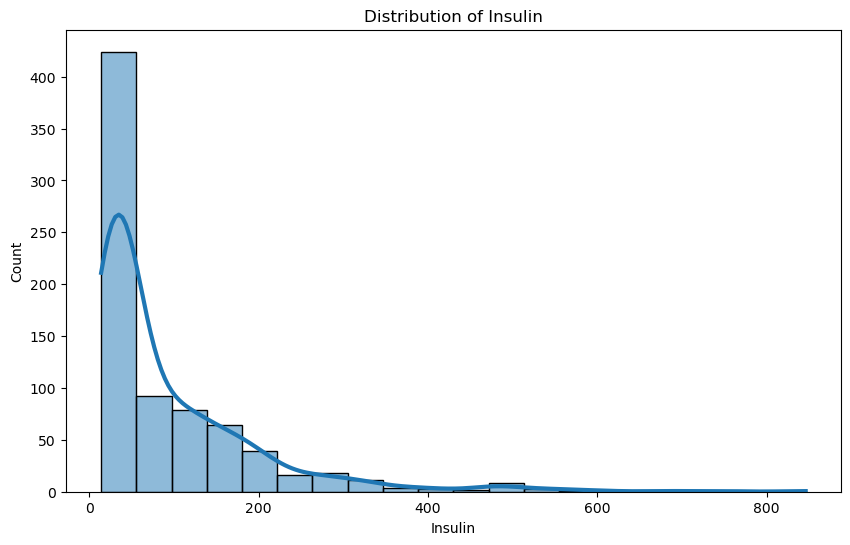

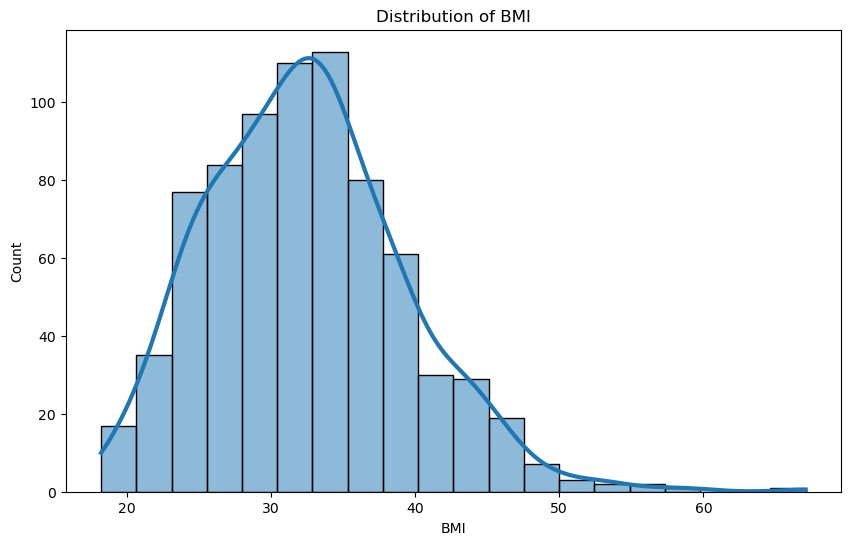

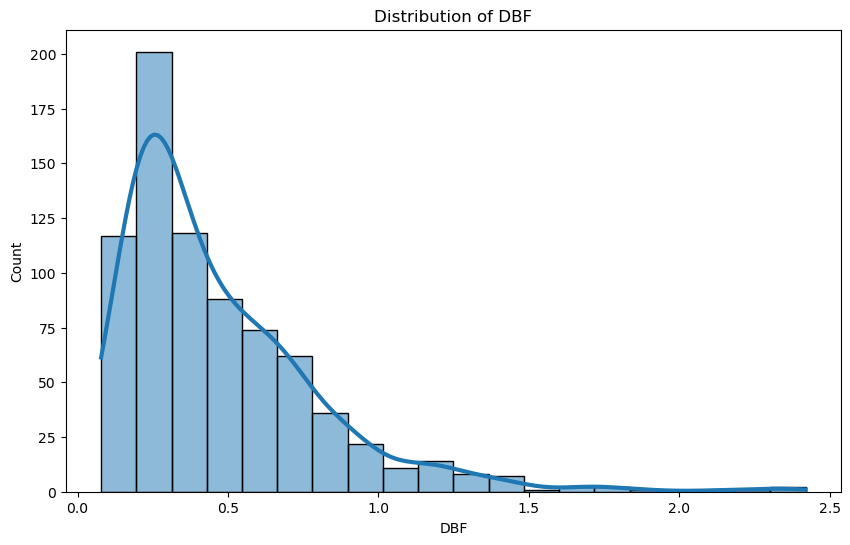

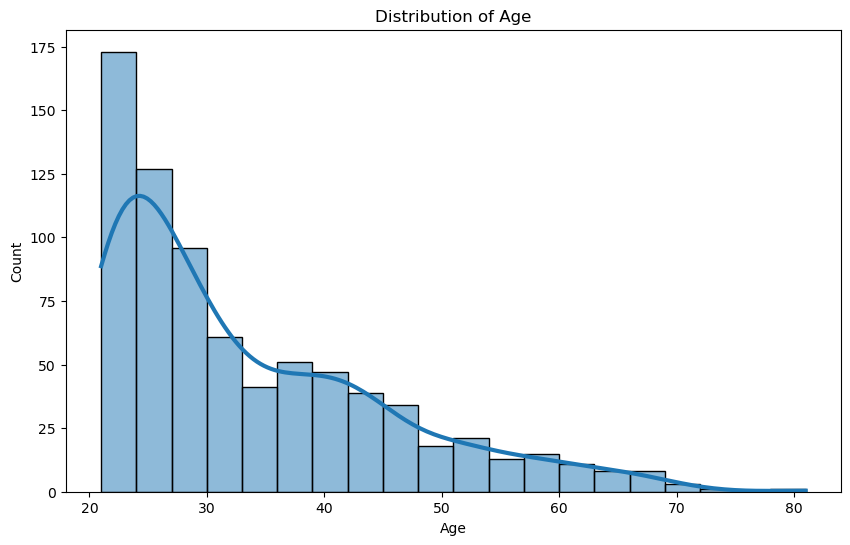

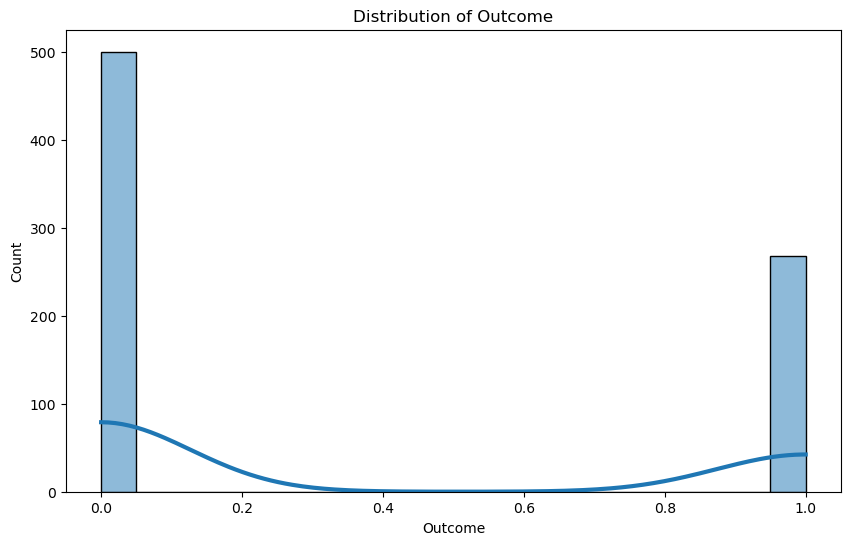

In [11]:
for col in data.columns:
    plt.figure(figsize=(10,6))
    sns.histplot(data[col],bins=20,kde=True,line_kws= {'linewidth':3})  
    plt.title(f'Distribution of {col}')
    plt.show()

#### 2.Boxplot

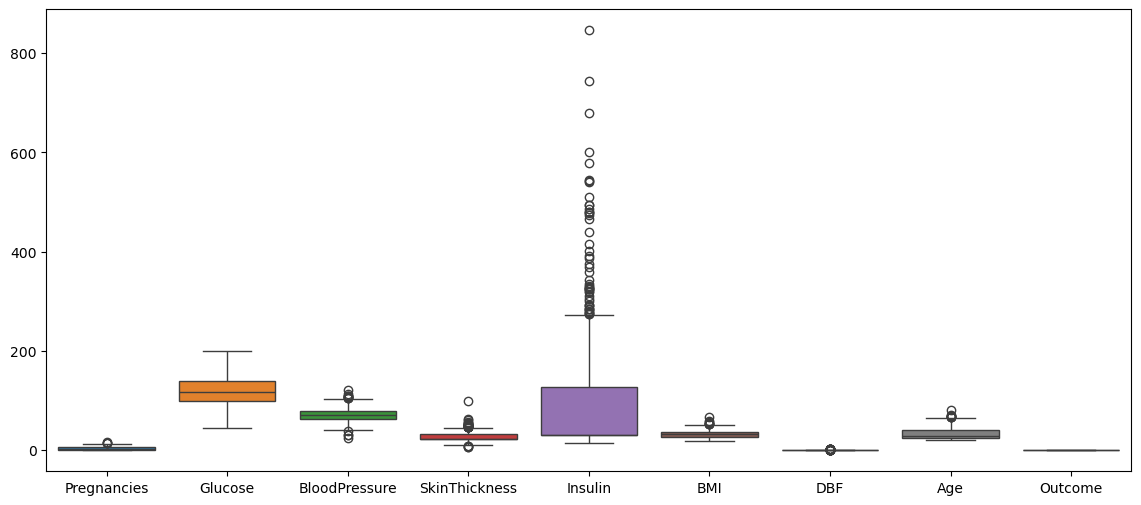

In [12]:
plt.figure(figsize=(14,6))
sns.boxplot(data)
plt.show()

#### 3. Pairplot

##### We have 9 columns so create 1 pairplot with all columns makes it messy. Soo we will split it into two graphs

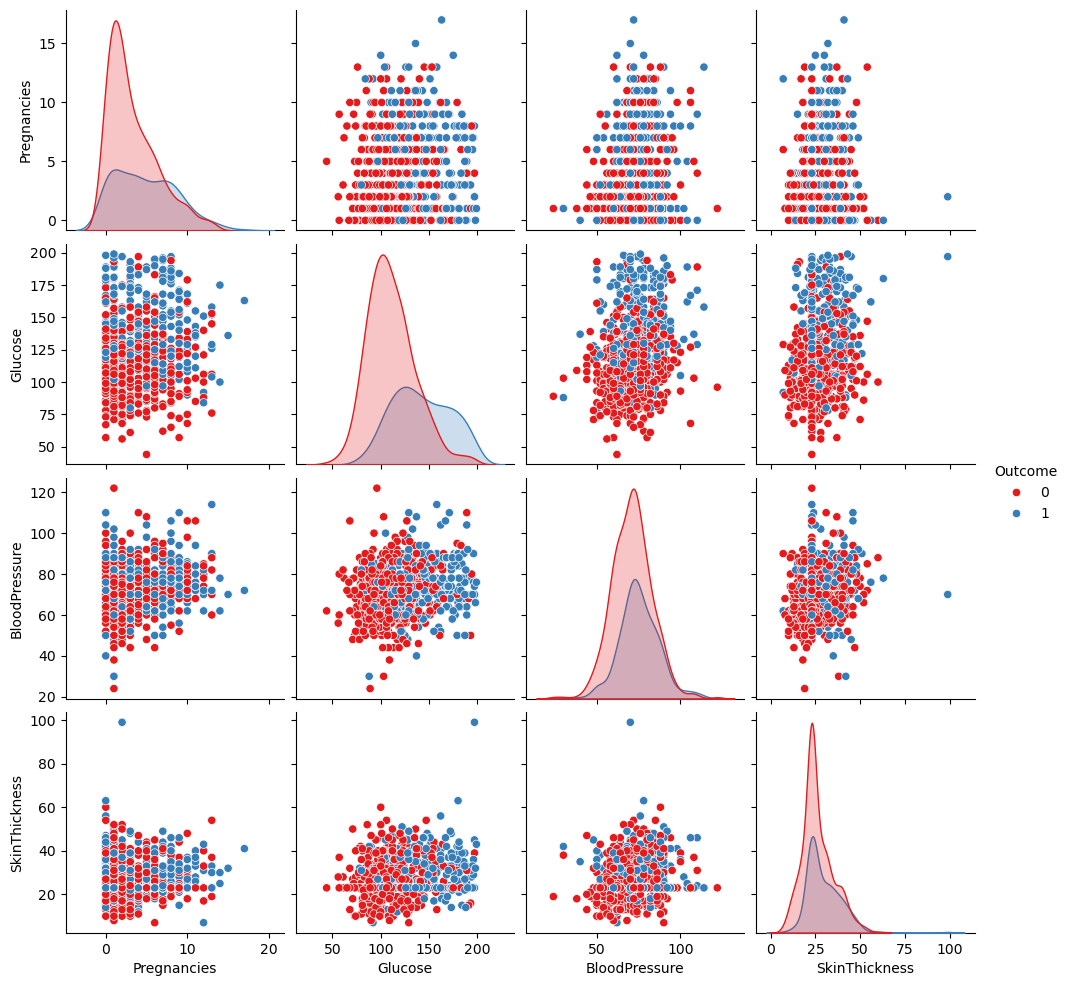

In [13]:
cols1 = list(data.columns[:4]) + ['Outcome']
sns.pairplot(data[cols1],hue='Outcome', palette = 'Set1')
plt.show()

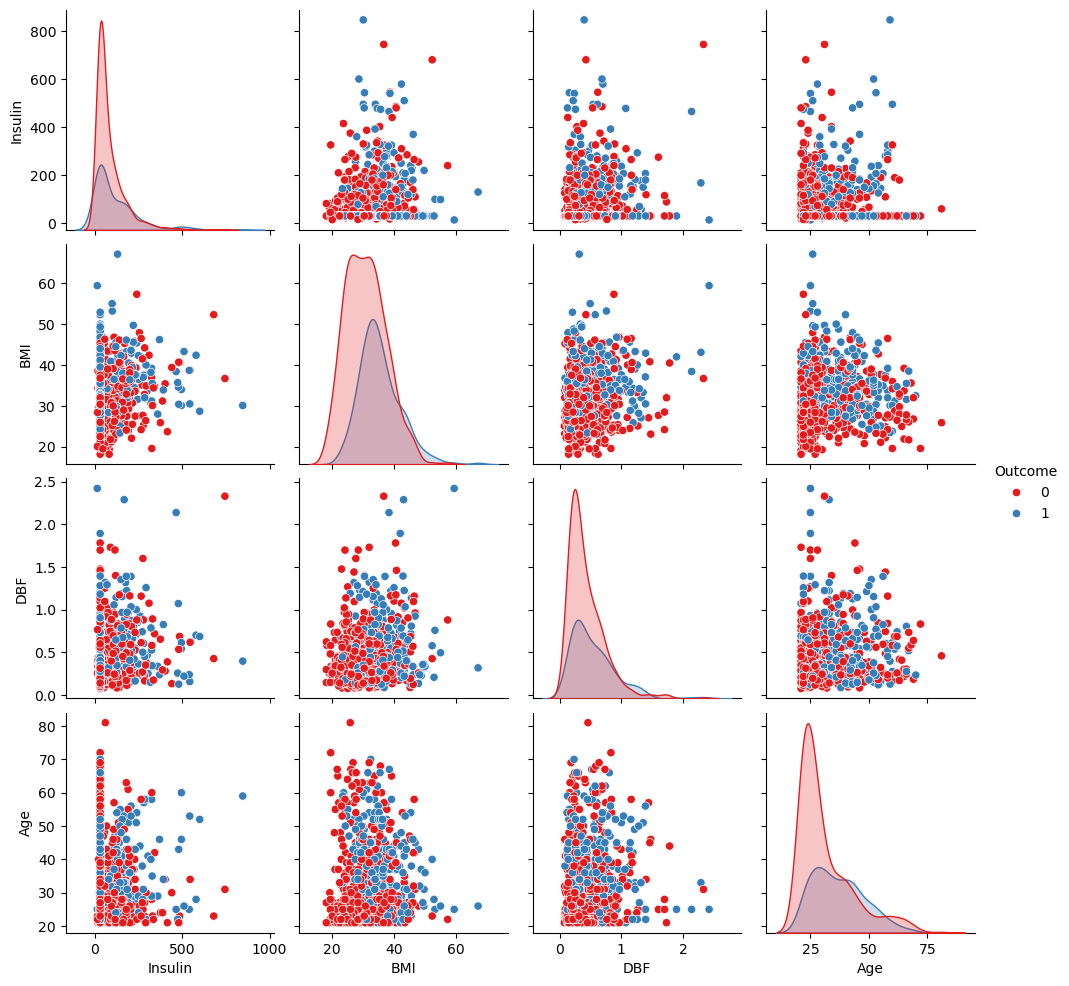

In [14]:
cols2 = list(data.columns[4:])
sns.pairplot(data[cols2],hue='Outcome', palette = 'Set1')
plt.show()

#### 4.Heatmap

##### To understand relationship between the attributes

<Axes: >

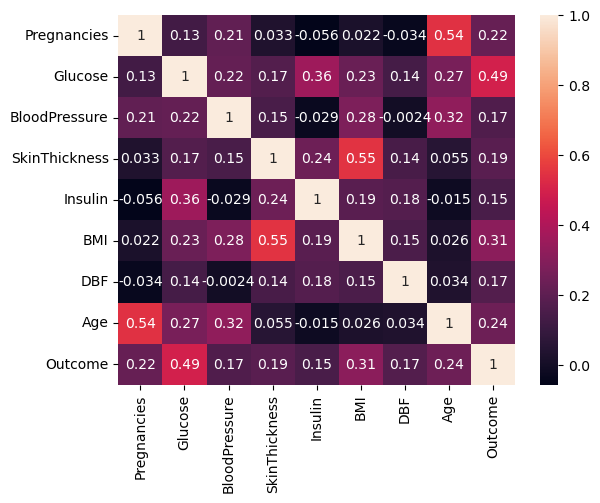

In [15]:
corr = data.corr()
sns.heatmap(corr,annot=True,linecolor='k')

### Insights
#### “Higher glucose → higher diabetes chances”
#### “BMI has strong impact”
#### “Age shows moderate correlation”

### Data Preprocessing

#### 1. Handle missing values (e.g., imputation).

In [16]:
data.isnull().sum()

Pregnancies      0
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
DBF              0
Age              0
Outcome          0
dtype: int64

#### No null Values are present

#### 2. Encode categorical variables.

#### All variables are numeric soo no need to encode any column

#### 3. Model Building:

#### Before building model we should clean the data first. According to above boxplots. Outliers are present in out dataset. Soo first replace the outliers

In [17]:
for col in data.columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5*IQR
    lower_bound = Q1 - 1.5*IQR
    outliers = data[(data[col]>upper_bound) | (data[col]<lower_bound)]
    print(f'{col} : {outliers.shape[0]} outliers')

Pregnancies : 4 outliers
Glucose : 0 outliers
BloodPressure : 14 outliers
SkinThickness : 35 outliers
Insulin : 49 outliers
BMI : 8 outliers
DBF : 29 outliers
Age : 9 outliers
Outcome : 0 outliers


In [18]:
for col in data.columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5*IQR
    lower_bound = Q1 - 1.5*IQR
    data[col] = data[col].clip(upper_bound,lower_bound)

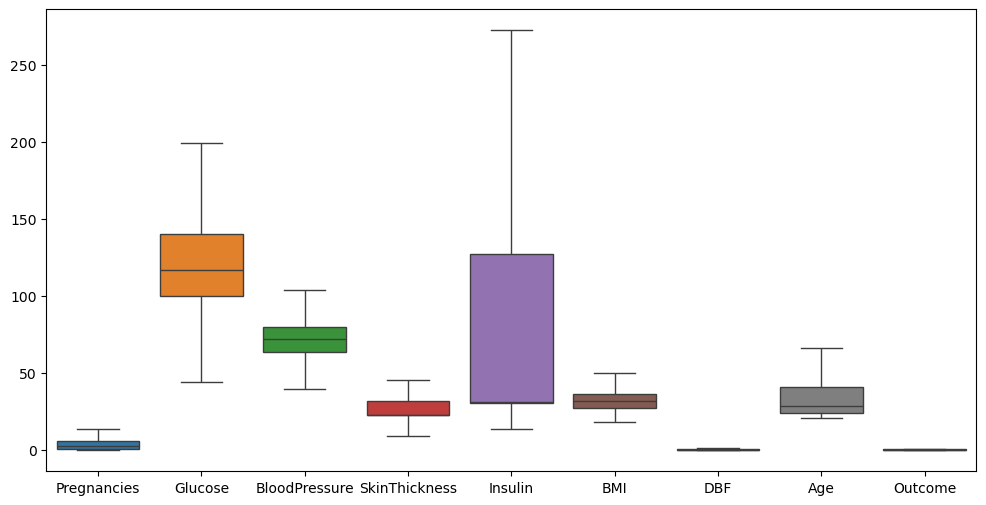

In [19]:
plt.figure(figsize=(12,6))
sns.boxplot(data)
plt.show()

#### Now We have cleaned data soo we can Build the model
#### 1. Standardize the data

In [20]:
from sklearn.preprocessing import StandardScaler

In [21]:
X = data.drop(columns='Outcome',axis=1)
y = data['Outcome']

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((614, 8), (154, 8), (614,), (154,))

In [24]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
X_train

array([[-0.5286616 , -1.25688146, -0.02015862, ..., -0.04167904,
        -0.53171951, -1.04683802],
       [ 1.60685303, -0.32605067,  0.83345473, ..., -0.60937049,
         2.6446253 ,  1.51360123],
       [-0.83373512,  0.57153617, -2.23955333, ..., -0.53467425,
         0.70904018, -0.95854701],
       ...,
       [ 1.91192654, -0.69173419,  1.17490007, ...,  1.99005877,
         2.41774353,  0.45410913],
       [-1.13880864,  0.63802409, -0.02015862, ...,  1.51200282,
        -0.88267725, -0.34050995],
       [-1.13880864,  0.10612077,  2.02851342, ..., -1.46090767,
        -0.68061068, -1.04683802]])

In [26]:
from sklearn.linear_model import LogisticRegression

In [27]:
model = LogisticRegression(max_iter=400)
model.fit(X_train,y_train)

LogisticRegression(max_iter=400)

### Model Evaluation:

#### Evaluate the performance of the model on the testing data using accuracy, precision, recall, F1-score, and ROC-AUC score. 

In [28]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,roc_curve,classification_report

In [29]:
yhat_test = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [30]:
print('Accuracy Score:',accuracy_score(y_test,yhat_test))
print('precision_score:',precision_score(y_test,yhat_test))
print('recall_score:',recall_score(y_test,yhat_test))
print('f1_score:',f1_score(y_test,yhat_test))
print('roc_auc_score',roc_auc_score(y_test,y_prob))

Accuracy Score: 0.7792207792207793
precision_score: 0.7058823529411765
recall_score: 0.6545454545454545
f1_score: 0.6792452830188679
roc_auc_score 0.8192837465564737


In [31]:
from sklearn.metrics import confusion_matrix,classification_report

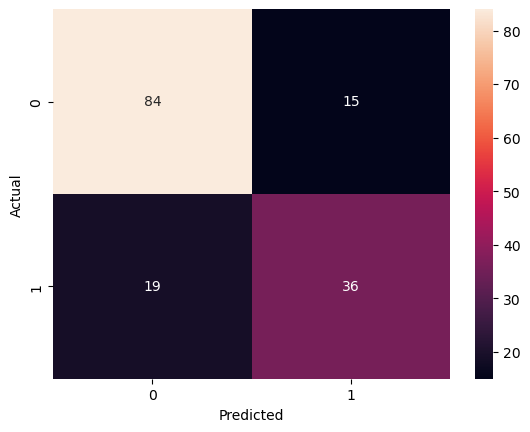

In [32]:
import seaborn as sns

cm = confusion_matrix(y_test, yhat_test)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [33]:
print("classification Report:\n",classification_report(y_test,yhat_test))

classification Report:
               precision    recall  f1-score   support

           0       0.82      0.85      0.83        99
           1       0.71      0.65      0.68        55

    accuracy                           0.78       154
   macro avg       0.76      0.75      0.76       154
weighted avg       0.78      0.78      0.78       154



In [34]:
yhat_train = model.predict(X_train)
cm = confusion_matrix(y_train, yhat_train)
cm

array([[356,  45],
       [ 91, 122]])

In [35]:
print("classification Report:\n",classification_report(y_train,yhat_train))

classification Report:
               precision    recall  f1-score   support

           0       0.80      0.89      0.84       401
           1       0.73      0.57      0.64       213

    accuracy                           0.78       614
   macro avg       0.76      0.73      0.74       614
weighted avg       0.77      0.78      0.77       614



#### Visualize the ROC curve.

In [36]:
def plot_roc(y,yhat):

    fpr,tpr, thresh = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    print(f'AUC: {auc}')
    plt.figure(figsize=(3,3))

    plt.title('AUC - ROC Curve', fontsize=15)
    plt.xlabel('False Positive Rate(FPR)')
    plt.ylabel('True Positive Rate(TPR)')
    plt.legend()
    plt.plot(fpr,tpr,marker = '.')
    plt.plot([0,1],[0,1], 'o--')
    plt.show()

AUC: 0.8192837465564737


/var/folders/c6/rh118pnd4z74yrqrmh0p58mc0000gn/T/ipykernel_3490/3701725920.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


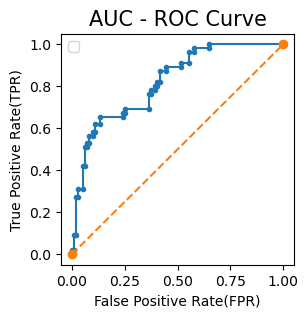

In [37]:
plot_roc(y_train,yhat_train)

AUC: 0.8192837465564737


/var/folders/c6/rh118pnd4z74yrqrmh0p58mc0000gn/T/ipykernel_3490/3701725920.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


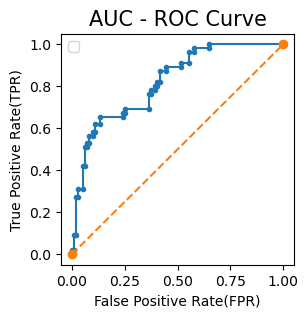

In [38]:
plot_roc(y_test,yhat_test)

In [39]:
coeff = pd.DataFrame(model.coef_[0], X.columns, columns=["Coefficient"])
coeff.sort_values(by="Coefficient", ascending=False)

,Coefficient
Glucose,1.124529
BMI,0.710935
Age,0.396547
DBF,0.275139
Pregnancies,0.197872
SkinThickness,0.058654
BloodPressure,-0.168277
Insulin,-0.208359


#### Glucose is the most significant predictor of diabetes
#### BMI also has strong influence
#### Age moderately contributes
#### Pregnancies have smaller effect

In [44]:
from pickle import dump


In [45]:
dump(model, open('model.pkl', 'wb'))
dump(scaler, open("scaler.pkl", "wb"))

### Interview Questions:

#### 1. What is the difference between precision and recall?
##### Precision → Out of predicted positive, how many are correct
##### Recall → Out of actual positive, how many we found

#### 2. What is cross-validation, and why is it important in binary classification?
#### Cross- Validation:
##### Cross-validation is a technique where data is split into multiple parts to evaluate model performance.

#### Why Important:
##### 1. Reduces overfitting
##### 2. Gives reliable performance
##### 3. Uses full dataset efficiently